## Setup

In [1]:
# imports 
%reload_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import xarray as xr
import pandas as pd


from scipy.signal import sosfiltfilt, butter, sosfilt, welch, savgol_filter
from scipy.stats import entropy, skew, kurtosis, pearsonr, spearmanr, ks_2samp, wasserstein_distance
from scipy.linalg import sqrtm, logm, norm
from scipy.spatial.distance import pdist, cdist
from sklearn.cluster import KMeans

os.environ['KERAS_BACKEND'] = 'torch'
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

import torch
import keras
from meegkit import dss

import mne
from mne.time_frequency import psd_array_welch
from src.EEGModalNet.models.WGAN_v0 import WGAN_GP_V0
from src.EEGModalNet.preprocessing.preprocessing import preprocess_data


# helper functions
def segment_data(x, time_dim):
    return torch.tensor(x.copy()).unfold(2, time_dim, time_dim).permute(0, 2, 3, 1).flatten(0, 1)

def reverse_segmentation(x, n_subjects):
    return x.unflatten(0, (n_subjects, -1)).flatten(1, 2).permute(0, 2, 1)
      
def generate_data(
    model,
    x,
    sub,
    pos,
    n_subjects,
    latent_dim=128,
    use_random_sub=False,
    device=None,
):
    """
    x:      (B, T, C) real data (only used for shape / optional stats later)
    sub:    (B, 1) subject ids for each segment
    pos:    (B, T, D_pos) positional encodings
    """

    model.generator.eval()

    if device is None:
        # infer device from model
        device = next(model.generator.parameters()).device
    else:
        device = torch.device(device)

    x      = x.float().to(device)
    sub    = sub.to(device)
    pos    = pos.to(device)

    B, T, C = x.shape
    x_gen   = torch.zeros_like(x)

    # assume balanced per-subject chunks
    bs = B // n_subjects
    n_chunks = B // bs

    for i in range(n_chunks):
        start = i * bs
        end   = (i + 1) * bs

        if use_random_sub:
            # sample labels uniformly in [0, n_subjects)
            sub_batch = torch.randint(0, n_subjects, (bs, 1), device=device)
        else:
            sub_batch = sub[start:end]

        z = torch.randn(bs, latent_dim, device=device)
        pos_batch = pos[start:end]

        with torch.no_grad():
            x_gen_batch = model.generator((z, sub_batch, pos_batch))
        x_gen[start:end] = x_gen_batch.cpu()

    # handle residual if B not divisible by bs
    tr_sh = (B // bs) * bs
    if tr_sh < B:
        res = B - tr_sh
        print("creating the residuals")

        if use_random_sub:
            sub_batch = torch.randint(0, n_subjects, (res, 1), device=device)
        else:
            sub_batch = sub[-res:]

        z = torch.randn(res, latent_dim, device=device)
        pos_batch = pos[-res:]

        with torch.no_grad():
            x_gen_tail = model.generator((z, sub_batch, pos_batch))
        x_gen[-res:] = x_gen_tail.cpu()

    return x_gen


def plot_psd_multi_channel(x, channels, ax, n_subjects=202, fmin=1, fmax=50, n_fft=512, label='real', db=True, color='blue',
                           reverse_first=True):
    if reverse_first:
        x = reverse_segmentation(x, n_subjects)
    else:
        x = x.permute(0, 2, 1)
    psd, freq = mne.time_frequency.psd_array_welch(x.numpy(), sfreq=128, fmin=fmin, fmax=fmax, n_fft=n_fft, verbose=False)
    if db:
        psd = 10*np.log10(psd)
    for i, c in enumerate(range(len(channels))):
        psd_ = psd[:, c, :]
        ax[i//4, i%4].plot(freq, psd_.mean(0), label=label, linewidth=2, color=color)
        ax[i//4, i%4].fill_between(freq, psd_.mean(0) - psd_.std(0), psd_.mean(0) + psd_.std(0), alpha=0.4, color=color)
        ax[i//4, i%4].set_title(f'Channel {channels[c]}', color='blue', fontsize=14, loc='left')
        ax[i//4, i%4].set_xlim([0.7, fmax])

def plot_time_domain(x, x_gen, time_dim, channels, ax, ch=0):
    x, x_gen = x[:, ch, :time_dim], x_gen[:, ch, :time_dim]
    real_data_avg = x.mean(0)
    fake_data_avg = x_gen.mean(0)
    ax.plot(fake_data_avg, label="Generated", color='orangered')
    ax.plot(real_data_avg, label="Real", color='navy', alpha=0.5)

    ax.fill_between(np.arange(time_dim),
                    real_data_avg - x.std(axis=0),
                    real_data_avg + x.std(axis=0),
                    alpha=0.4, color='navy')
    
    ax.fill_between(np.arange(time_dim),
            fake_data_avg - x_gen.std(axis=0),
            fake_data_avg + x_gen.std(axis=0),
            alpha=0.4, color='orangered')

    ax.set_title(f'Channel {channels[ch]}', fontsize=14, color='blue', loc='left')
    ax.set_xlim([0, time_dim])


def plot_psd_individual_subjects(reversed_x, channels, ax, n_sub_plotted=2, fmin=1, fmax=60, n_fft=512, color='blue'):
    psd, freq = mne.time_frequency.psd_array_welch(reversed_x[:n_sub_plotted], sfreq=128, fmin=fmin, fmax=fmax, n_fft=n_fft, verbose=False)
    psd = 10*np.log10(psd)
    for n in range(n_sub_plotted):
        for i, c in enumerate(range(len(channels))):
            psd_ = psd[n, c, :]
            ax[i//4, i%4].plot(freq, psd_, label=f'subject {n}', linewidth=2)
            ax[i//4, i%4].set_title(f'Channel {channels[c]}', color='blue', fontsize=14, loc='left')
            ax[i//4, i%4].set_xlim([0.7, fmax])

def calculate_psd_different_methods(x, x_gen, n_subjects, psd_method='reorder_first'):

    if psd_method == 'reverse_first':
        psd, freq = psd_array_welch(reverse_segmentation(x, n_subjects).numpy(), sfreq=128, fmin=1, fmax=60, n_fft=512, verbose=False)
        psd_gen, freq_gen = psd_array_welch(reverse_segmentation(x_gen, n_subjects).numpy(), sfreq=128, fmin=1, fmax=60, n_fft=512, verbose=False)

    if psd_method == 'flat_first':
        psd, freq = psd_array_welch(x.flatten(0, 1).permute(1, 0).numpy(), sfreq=128, fmin=1, fmax=60, n_fft=512, verbose=False)
        psd_gen, freq_gen = psd_array_welch(x_gen.flatten(0, 1).permute(1, 0).numpy(), sfreq=128, fmin=1, fmax=60, n_fft=512, verbose=False)

    if psd_method == 'reorder_first':
        psd, freq = psd_array_welch(x.permute(0, 2, 1).numpy(), sfreq=128, fmin=1, fmax=50, n_fft=512, verbose=False)
        psd_gen, freq_gen = psd_array_welch(x_gen.permute(0, 2, 1).numpy(), sfreq=128, fmin=1, fmax=50, n_fft=512, verbose=False)
    
    return psd, psd_gen, freq

def time_domain_features_multi_channel(x, axis=-1):  # x: (n_samples, n_channels, n_timepoints)
    mean = np.mean(x, axis=axis)
    std = np.std(x, axis=axis)
    skewness = skew(x, axis=axis)
    kurtosis_ = kurtosis(x, axis=axis)
    rms = np.sqrt(np.mean(x**2, axis=axis))
    return np.stack([mean, std, skewness, kurtosis_, rms], axis=-1)  # (n_samples, n_channels, n_features)

def hjorth_parameters_multi_channel(signal, axis=-1): 
    activity = np.var(signal, axis=axis)
    first_derivative = np.diff(signal, axis=axis)
    mobility = np.sqrt(np.var(first_derivative, axis=axis) / activity)
    second_derivative = np.diff(first_derivative, axis=axis)
    complexity = np.sqrt(np.var(second_derivative, axis=axis) / np.var(first_derivative, axis=axis)) / mobility
    return np.stack([activity, mobility, complexity], axis=-1)

def spectral_features_multi_channel(signal, fs=128, nperseg=512):
    f, Pxx = welch(signal, fs=fs, nperseg=nperseg, axis=-1)
    total_power = np.sum(Pxx, axis=-1)
    delta = np.sum(Pxx[:, :, (f >= 0.25) & (f < 4)], axis=-1) / total_power
    theta = np.sum(Pxx[:, :, (f >= 4) & (f < 8)], axis=-1) / total_power
    alpha = np.sum(Pxx[:, :, (f >= 8) & (f < 13)], axis=-1) / total_power
    beta = np.sum(Pxx[:, :, (f >= 13) & (f <= 30)], axis=-1) / total_power
    gamma = np.sum(Pxx[:, :, (f > 30) & (f <= 50)], axis=-1) / total_power
    pxx_entropy = entropy(Pxx, axis=-1)
    return np.stack([delta, theta, alpha, beta, gamma, pxx_entropy], axis=-1)

def aggregate_features(real_signal, gen_signal):
    # Extract features
    real_time_features = time_domain_features_multi_channel(real_signal)
    real_hjorth_features = hjorth_parameters_multi_channel(real_signal)
    real_spectral_features = spectral_features_multi_channel(real_signal)
    
    gen_time_features = time_domain_features_multi_channel(gen_signal)
    gen_hjorth_features = hjorth_parameters_multi_channel(gen_signal)
    gen_spectral_features = spectral_features_multi_channel(gen_signal)
    
    # Concatenate features
    real_features = np.concatenate([real_time_features, real_hjorth_features, real_spectral_features], axis=-1)
    gen_features = np.concatenate([gen_time_features, gen_hjorth_features, gen_spectral_features], axis=-1)
    
    # # Reshape to 2D for FID
    # real_features = real_features.reshape(real_features.shape[0], -1)  # Flatten across channels
    # gen_features = gen_features.reshape(gen_features.shape[0], -1)
    
    return real_features, gen_features

def compute_fid(x_features, y_features):
    # Mean and covariance
    mean1, cov1 = x_features.mean(axis=0), np.cov(x_features, rowvar=False)
    mean2, cov2 = y_features.mean(axis=0), np.cov(y_features, rowvar=False)
    # Mean difference
    mean_diff = np.sum((mean1 - mean2)**2)
    
    # Covariance square root
    covmean = sqrtm(cov1 @ cov2)
    
    # Numerical stability
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    
    # FID formula
    fid = mean_diff + np.trace(cov1 + cov2 - 2 * covmean)
    return fid


## Data

In [2]:
# Data Parameters
FILTERING = True
PREPROCESSING = True
LINE_NOISE_REMOVAL = True
TIME_DIM = 512
N_SUBJECTS = 5
CONDITION = 'EO'
EEG_DATA_PATH = f'data/LEMON_data/{CONDITION}_ch-8_sf-128.nc5'
CHANNELS = ['O1', 'O2', 'P1', 'P2', 'C1', 'C2', 'F1', 'F2']

# Model parameters
LATENT_DIM = 128

# REAL DATA
xarray = xr.open_dataarray(EEG_DATA_PATH, engine='h5netcdf')

sub_id = np.random.randint(0, 202, N_SUBJECTS)
x = xarray.sel(subject=xarray.subject[sub_id], channel=CHANNELS)
x = x.to_numpy()

if PREPROCESSING:
    x = preprocess_data(x, sampling_rate=128)

if FILTERING:
    sos = butter(4, 0.5, btype='high', fs=128, output='sos')
    x = sosfiltfilt(sos, x, axis=-1)

if LINE_NOISE_REMOVAL:
    x, _ = dss.dss_line(x.T, fline=50, sfreq=128, nremove=1)
    x = x.T

x = segment_data(x, TIME_DIM)
sub = torch.tensor(np.arange(0, N_SUBJECTS).repeat(x.shape[0]//N_SUBJECTS)[:, np.newaxis])

fill_v = 0 if CONDITION == 'EC' else 1
state = torch.full_like(sub, fill_value=0)   # (B,1)
data = {'x': x, 'sub': sub, 'pos': state}

>>>>Corrected Mean: -6.805949141382086e-06, Std: 3.405148576691085e-05, Max: 0.00019643324738270865, Min: -0.00018373211854054715
>>>>Scaled Mean: 0.020260487757513414, Std: 0.9432304885670088, Max: 10.54824295310514, Min: -10.948883513425438
>>>>Normalized Mean: -1.509903313490213e-16, Std: 1.0000000000000007, Max: 8.70309684894868, Min: -7.543149357370845
>>>>Clamped Mean: -1.509903313490213e-16, Std: 1.0000000000000007, Max: 8.70309684894868, Min: -7.543149357370845
Power of components removed by DSS: 0.02


## Training

In [29]:
from src.EEGModalNet.models.FiLMGAN import FiLMGAN

model = FiLMGAN(512, 8, 128, 202, True, True)

model.compile(keras.optimizers.Adam(1e-4, beta_1=0.5), keras.optimizers.Adam(1e-4, beta_1=0.5), 1)
model.critic.output_features = False

history = model.fit(data, epochs=20, batch_size=64)

Epoch 1/20
 2/10 ━━━━━━━━━━━━━━━━━━━━ 3s 461ms/step - 1 d_loss: 0.6051 - 10 g_state_subject: 1.0000 - 11 g_sub_mid: 1.0000 - 12 g_state_mid: 1.0000 - 2 g_loss: -0.0141 - 3 critic_grad_norm: 0.9320 - 4 gp: 0.9817 - 5 real_pred: 0.1978 - 6 fake_pred: 0.0218 - 7 real_pred_std: 0.0451 - 8 fake_pred_std: 4.9382e-05 - 9 g_sub_subject: 1.0000 - loss: 0.2844

KeyboardInterrupt: 

In [ ]:
model.critic.output_features = True

out = torch.tensor(model.critic.predict(data))

out.shape

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


torch.Size([600, 16512])

In [27]:
16512 / 4

4128.0

## Load ckpt

In [3]:
# fake data
CHECKPOINTS_PATH = 'logs/eo/20260221_v2_epoch_20.model.keras'

from src.EEGModalNet.models.FiLMGAN import FiLMGAN

model = keras.saving.load_model(CHECKPOINTS_PATH, custom_objects={'FiLMGAN': FiLMGAN}, compile=False)

with torch.no_grad():
     x_gen = generate_data(model, x, sub, state, N_SUBJECTS, latent_dim=LATENT_DIM, use_random_sub=False).cpu()

## Stats

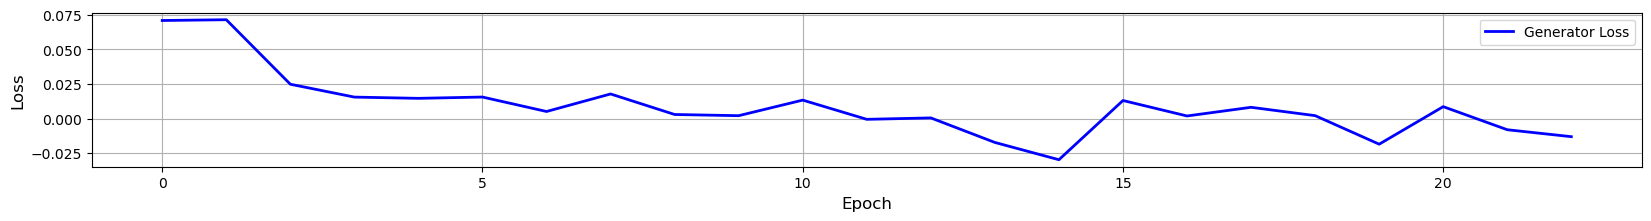

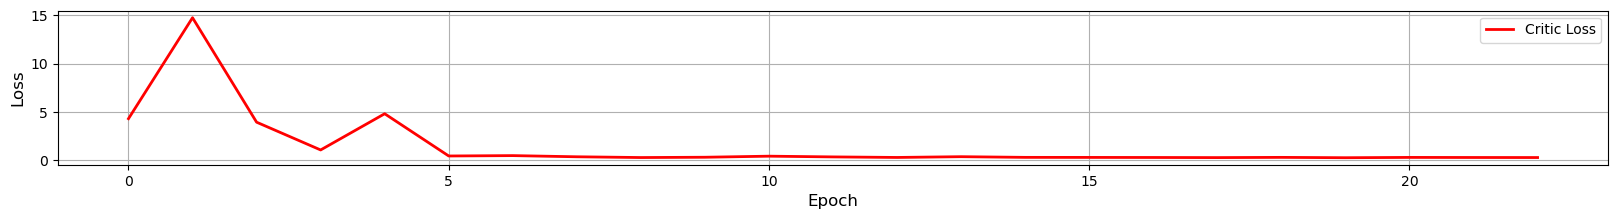

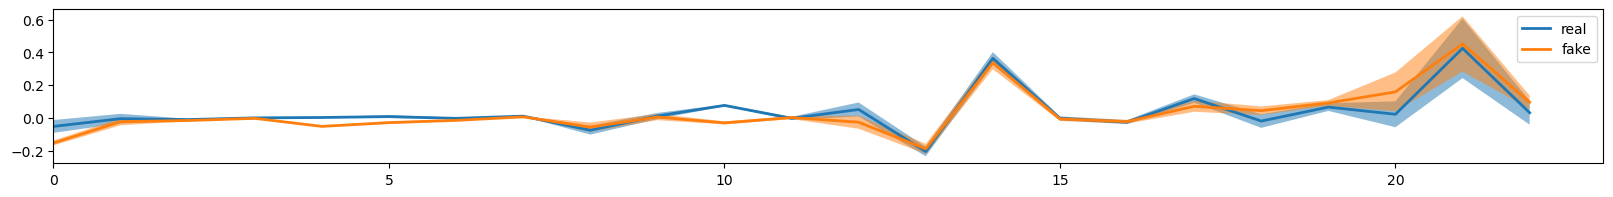

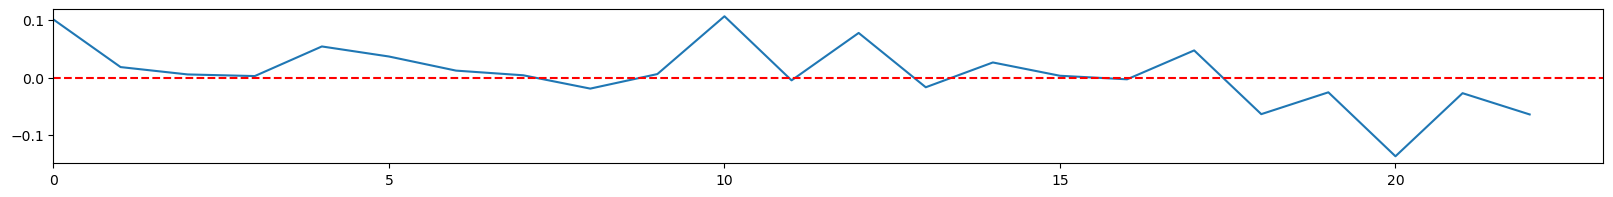

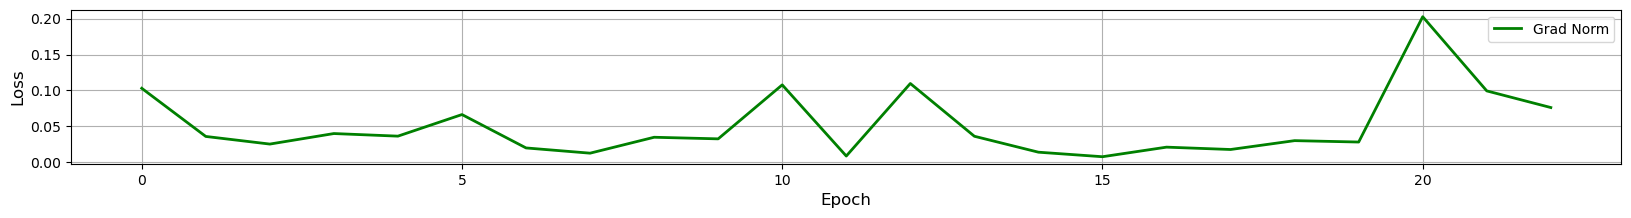

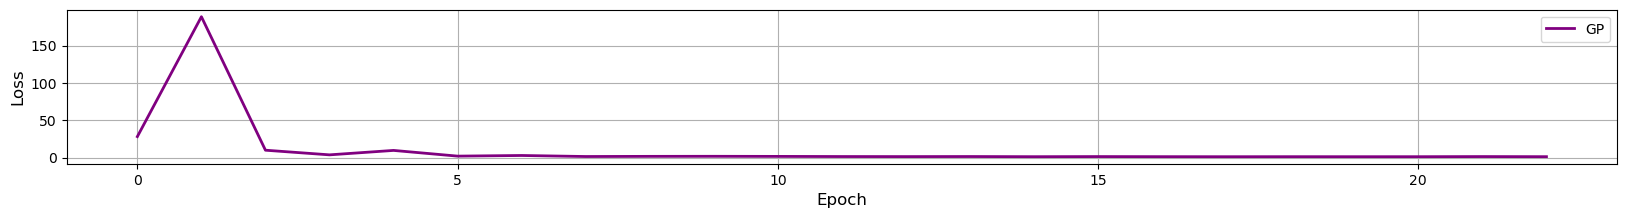

In [4]:
## Stats
# import matplotlib.pyplot as plt
# import pandas as pd
MODEL_ID = '20260221_v2'
EPOCH = 200
STATS_PATH = f'logs/eo/{MODEL_ID}.csv'

def plot_loss(data, label, color='red'):
    plt.plot(data, label=label, color=color, linestyle='-', linewidth=2)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.grid(True)
    plt.legend()


ep = None
bounded = (0, ep)
stats = pd.read_csv(STATS_PATH, index_col=0)
plt.figure(figsize=(20, 2))
plot_loss(stats.loc[bounded[0]:bounded[1], '2 g_loss'], label='Generator Loss', color='blue')
plt.figure(figsize=(20, 2))
plot_loss(stats.loc[bounded[0]:bounded[1], '1 d_loss'], label='Critic Loss', color='red')

plt.figure(figsize=(20, 2))
plt.plot(stats.loc[bounded[0]:bounded[1], '5 real_pred'], label='real', linewidth=2)
plt.fill_between(stats.index, stats['5 real_pred'] - stats['7 real_pred_std'], stats['5 real_pred'] + stats['7 real_pred_std'], alpha=0.5)
plt.plot(stats.loc[bounded[0]:bounded[1], '6 fake_pred'], label='fake', linewidth=2)
plt.fill_between(stats.index, stats['6 fake_pred'] - stats['8 fake_pred_std'], stats['6 fake_pred'] + stats['8 fake_pred_std'], alpha=0.5)
plt.legend()
plt.xlim(bounded[0], bounded[1])
limmin = stats.loc[bounded[0]:bounded[1], '6 fake_pred'].min()
limmax = stats.loc[bounded[0]:bounded[1], '6 fake_pred'].max()
# plt.ylim(limmin, limmax)

plt.figure(figsize=(20, 2))
plt.plot(stats['5 real_pred'] - stats['6 fake_pred'])
plt.xlim(bounded[0], bounded[1])
plt.axhline(0, color='red', linestyle='--')
# plt.ylim(-30, 30)

plt.figure(figsize=(20, 2))
plot_loss(stats.loc[:ep, '3 critic_grad_norm'], label='Grad Norm', color='green')
plt.figure(figsize=(20, 2))
plot_loss(stats.loc[:ep, '4 gp'], label='GP', color='purple')

## Repetition check

In [5]:
def reverse_segmentation(x, n_subjects):
    return x.unflatten(0, (n_subjects, -1)).flatten(1, 2).permute(0, 2, 1)

x_gen_reversed = reverse_segmentation(x, N_SUBJECTS)
blocks = x_gen_reversed.reshape(-1, 512, 8)      # no mean
blocks = (blocks - blocks.mean(axis=(1,2), keepdims=True)) / blocks.std(axis=(1,2), keepdims=True)

X = blocks.reshape(blocks.shape[0], -1)
corr_ = np.corrcoef(X)

# exclude diagonal
iu = np.triu_indices_from(corr_, k=1)
print(corr_[iu].mean())

# x_gen_reversed: [S, T_total, C]
x_gen_reversed = reverse_segmentation(x_gen, N_SUBJECTS)
# x_reversed = reverse_segmentation(x, N_SUBJECTS)
x_mean = x_gen_reversed.mean(0).permute(1, 0)

# reshape into blocks of 512
blocks = x_mean.reshape(-1, 512, x_mean.shape[-1])  # [n_blocks, 512, C]

# compare block 0,1,2,...
corr = np.corrcoef(blocks.reshape(blocks.shape[0], -1))
print(corr.mean())

0.004912834700820897
0.9999086777930869


## Intermediate layers

In [6]:
@torch.no_grad()
def critic_feature_separation(critic, real_batch, fake_batch, sub_ids, state_ids, feature_dim, eps=1e-8):
    """
    real_batch: (B, T, C) or your input format for critic
    fake_batch: (B, T, C)
    sub_ids:    (B,) long/int
    state_ids:  (B,) long/int
    feature_dim: base C used in critic (the one you called feature_dim)
    Returns:
        per_dim: dict with delta and delta_norm tensors of shape (D_feat,)
        per_block: dict with block-wise scalars
    """

    # 1) Extract features
    # feats_r = critic.call({'x':real_batch, 'sub':sub_ids, 'pos':state_ids})  # (B, D_feat)
    # feats_f = critic.call({'x':fake_batch, 'sub':sub_ids, 'pos':state_ids})  # (B, D_feat)

    feats_r = critic.extract_features(real_batch, sub_ids, state_ids)  # (B, D_feat)
    feats_f = critic.extract_features(fake_batch, sub_ids, state_ids)  # (B, D_feat)

    # Ensure torch tensors
    if not isinstance(feats_r, torch.Tensor):
        feats_r = torch.as_tensor(feats_r)
    if not isinstance(feats_f, torch.Tensor):
        feats_f = torch.as_tensor(feats_f)

    # 2) Per-dimension delta
    delta = (feats_r - feats_f).abs().mean(dim=0)  # (D_feat,)

    # 3) Normalization by variability (per dim)
    std_r = feats_r.std(dim=0, unbiased=False)
    std_f = feats_f.std(dim=0, unbiased=False)
    delta_norm = delta / (std_r + std_f + eps)

    # 4) Block slicing
    C1 = feature_dim
    C2 = 2 * feature_dim
    C3 = 8 * feature_dim
    C4 = 16 * feature_dim

    idx1 = slice(0, C1)
    idx2 = slice(C1, C1 + C2)
    idx3 = slice(C1 + C2, C1 + C2 + C3)
    idx4 = slice(C1 + C2 + C3, C1 + C2 + C3 + C4)
    # idx5 = slice(C1 + C2 + C3 + C4, -1)

    def block_stats(x, sl):
        return x[sl].mean().item()

    per_block = {
        "h1_delta":      block_stats(delta, idx1),
        "h2_delta":      block_stats(delta, idx2),
        "h3_delta":      block_stats(delta, idx3),
        # "h4_delta":      block_stats(delta, idx4),
        # "h5_delta":      block_stats(delta, idx5),
        "h1_delta_norm": block_stats(delta_norm, idx1),
        "h2_delta_norm": block_stats(delta_norm, idx2),
        "h3_delta_norm": block_stats(delta_norm, idx3),
        # "h4_delta_norm": block_stats(delta_norm, idx4),
        # "h4_delta_norm": block_stats(delta_norm, idx5),
    }

    per_dim = {"delta": delta, "delta_norm": delta_norm}
    return per_dim, per_block, delta, feats_r


In [7]:
b = 128
critic = model.critic
per_dim, per_block, delta, f_r = critic_feature_separation(
    critic=critic,
    real_batch=x[:b].float().to('mps'),
    fake_batch=x_gen[:b].float().to('mps'),
    sub_ids=sub[:b].to('mps'),
    state_ids=state[:b].to('mps'),
    feature_dim=8,
)

print(per_block)

{'h1_delta': 0.025396721437573433, 'h2_delta': 0.03599495068192482, 'h3_delta': 0.004858892876654863, 'h1_delta_norm': 0.6614645719528198, 'h2_delta_norm': 1.5601887702941895, 'h3_delta_norm': 1.1965891122817993}


In [8]:
critic = model.critic
critic.output_features = True

out = critic.predict({'x':x[128:128+32], 'sub':sub[128:128+32], 'pos':state[128:128+32]})

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


In [ ]:
# median var: 7.489374524993764e-07 top-50 mean var: 0.001757840858772397

In [9]:
critic = model.critic
with torch.no_grad():
    feat = critic.output_features = True
    z = critic.predict({'x': x, 'sub': sub, 'pos': state})  # (B, D)
    critic.output_features = False

    var = torch.tensor(z.var(axis=0))           # (D,)
    topk = torch.topk(var, k=50).values
    print("median var:", var.median().item(), "top-50 mean var:", topk.mean().item())

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
median var: 1.2823061013023107e-07 top-50 mean var: 7.964680662553292e-06


In [10]:
u, s, v = torch.pca_lowrank(torch.tensor(z), q=20)
print("top singular values:", s)

top singular values: tensor([0.9270, 0.5821, 0.5489, 0.5076, 0.4908, 0.4671, 0.4411, 0.3976, 0.3662,
        0.3344, 0.3314, 0.3282, 0.3125, 0.2892, 0.2827, 0.2748, 0.2595, 0.2403,
        0.2296, 0.2165])


In [12]:
with torch.no_grad():
    z = critic.predict({'x': x, 'sub': sub, 'pos': state})
    critic.output_features = False

    out = critic.predict({'x': x, 'sub': sub, 'pos': state}).squeeze()

    z = torch.tensor(z)
    out = torch.tensor(out)

    zn = z.norm(dim=1)

    # manual correlation (numerically safer)
    zn_centered = zn - zn.mean()
    out_centered = out - out.mean()

    corr = (zn_centered * out_centered).mean() / (
        zn_centered.std() * out_centered.std() + 1e-8
    )

    print("corr(||feat||, out):", corr.item())


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
corr(||feat||, out): -0.9867261648178101


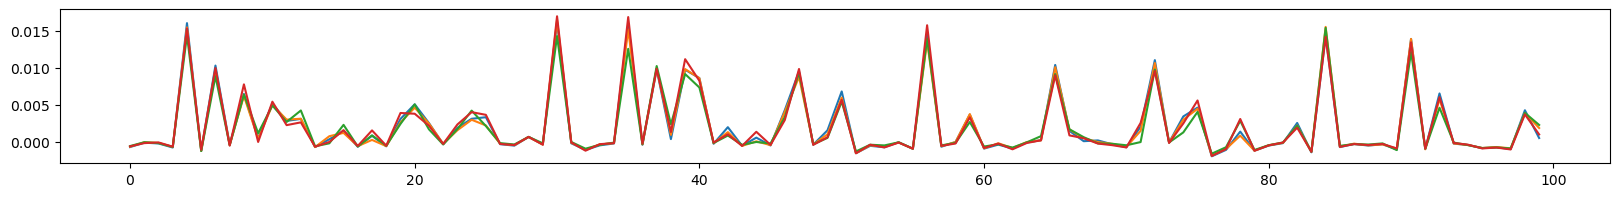

In [11]:
plt.figure(figsize=(20, 2))
plt.plot(out[00, 100:200])
plt.plot(out[-1, 100:200])
plt.plot(out[20, 100:200])
plt.plot(out[30, 100:200])

## Quality of the Generated Data

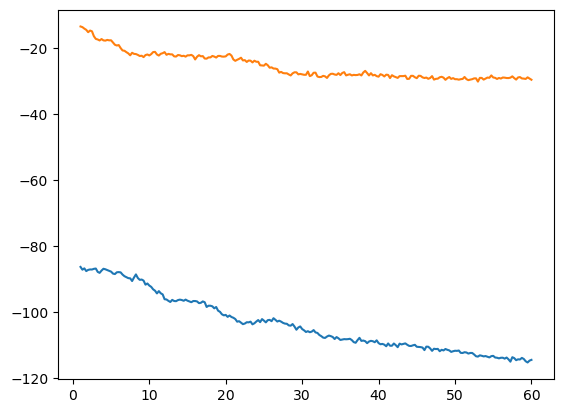

In [13]:
# x_gen_reversed.shape
x_reversed = reverse_segmentation(x, N_SUBJECTS)
s = 2

psd, freqs = mne.time_frequency.psd_array_welch(x_gen_reversed[s].numpy(), sfreq=128, fmin=1, fmax=60, n_fft=512, verbose=False)
psd_real, freqs = mne.time_frequency.psd_array_welch(x_reversed[s].numpy(), sfreq=128, fmin=1, fmax=60, n_fft=512, verbose=False)
psd = 10*np.log10(psd)
psd_real = 10*np.log10(psd_real)

ch = 6
plt.plot(freqs, psd[ch])
plt.plot(freqs, psd_real[ch])

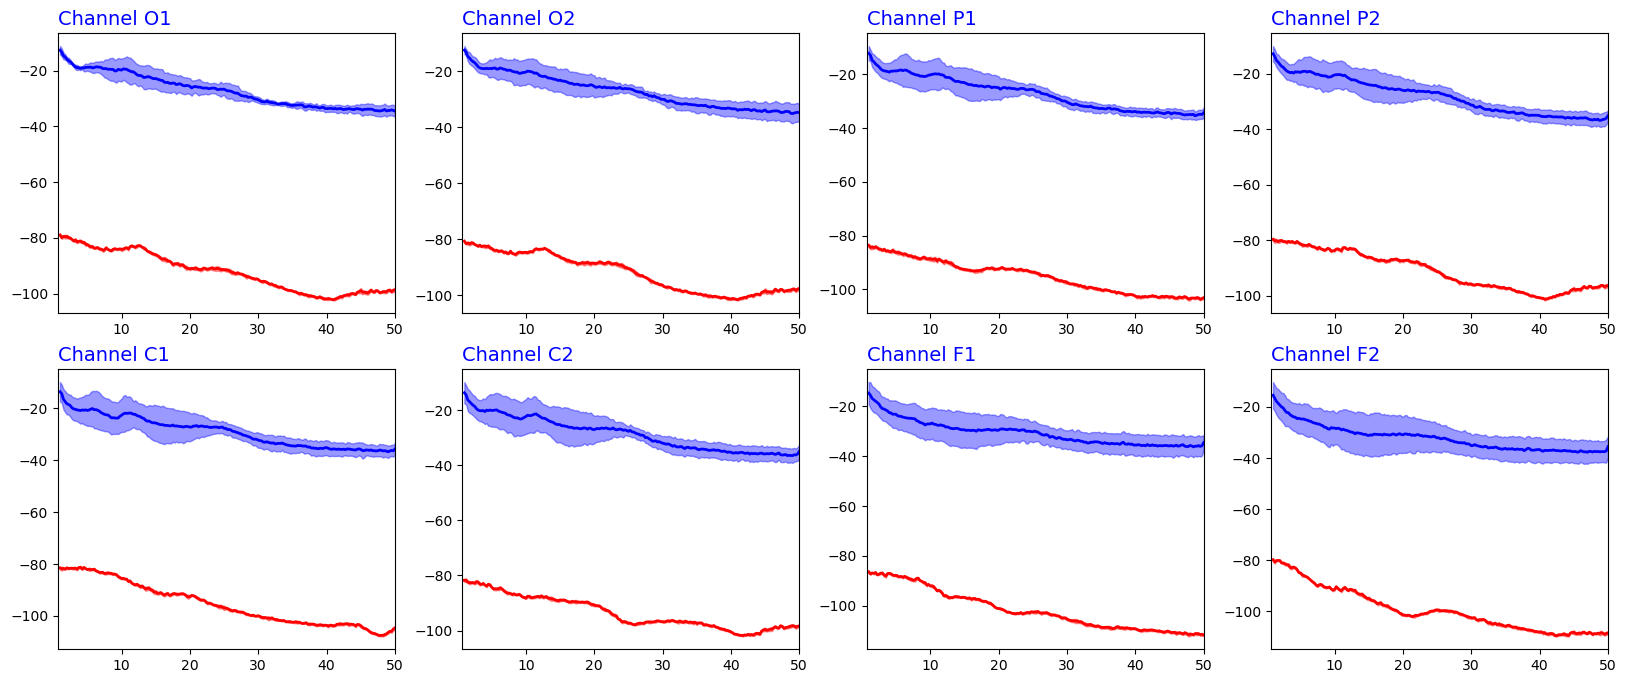

In [14]:
def reverse_segmentation(x, n_subjects):
    return x.unflatten(0, (n_subjects, -1)).flatten(1, 2).permute(0, 2, 1)

x_gen_reversed = reverse_segmentation(x_gen, N_SUBJECTS)
x_reversed = reverse_segmentation(x, N_SUBJECTS)

def plot_psd_multi_channel(x, channels, ax, n_subjects=202, fmin=1, fmax=50, n_fft=512, label='real', db=True, color='blue',
                           reverse_first=True):
    psd, freq = mne.time_frequency.psd_array_welch(x.numpy(), sfreq=128, fmin=fmin, fmax=fmax, n_fft=n_fft, verbose=False)
    if db:
        psd = 10*np.log10(psd)
    for i, c in enumerate(range(len(channels))):
        psd_ = psd[:, c, :]
        ax[i//4, i%4].plot(freq, psd_.mean(0), label=label, linewidth=2, color=color)
        ax[i//4, i%4].fill_between(freq, psd_.mean(0) - psd_.std(0), psd_.mean(0) + psd_.std(0), alpha=0.4, color=color)
        ax[i//4, i%4].set_title(f'Channel {channels[c]}', color='blue', fontsize=14, loc='left')
        ax[i//4, i%4].set_xlim([0.7, fmax])

channels = CHANNELS

_, ax = plt.subplots(2, 4, figsize=(20, 8))
plot_psd_multi_channel(x_reversed, CHANNELS, ax, n_subjects=N_SUBJECTS, reverse_first=True)
plot_psd_multi_channel(x_gen_reversed, CHANNELS, ax, n_subjects=N_SUBJECTS, reverse_first=True, color='red')

## Critic Performance

In [19]:
EPOCH = 60
# CHECKPOINTS_PATH = f'logs/eo/20260215_v2_epoch_80.model.keras'

from src.EEGModalNet.models.FiLMGAN import FiLMGAN

model = keras.saving.load_model(CHECKPOINTS_PATH, custom_objects={'FiLMGAN': FiLMGAN}, compile=False)

with torch.no_grad():
     x_gen = generate_data(model, x, sub, state, N_SUBJECTS, latent_dim=LATENT_DIM, use_random_sub=False).cpu()

In [20]:
def critic_scores(x):
    l = len(x)
    critic_scores = torch.zeros(l)
    for i in range(int(l//100)):
        generate_data = {'x': x[i*100:(i+1)*100].to('mps'), 'sub': sub[i*100:(i+1)*100].to('mps'), 'pos': state[:100].to('mps')}
        critic_scores[i*100:(i+1)*100] = model.critic(generate_data).squeeze()
    return critic_scores

with torch.no_grad():
    fake_pred = critic_scores(x.float())
    real_pred = critic_scores(x_gen)

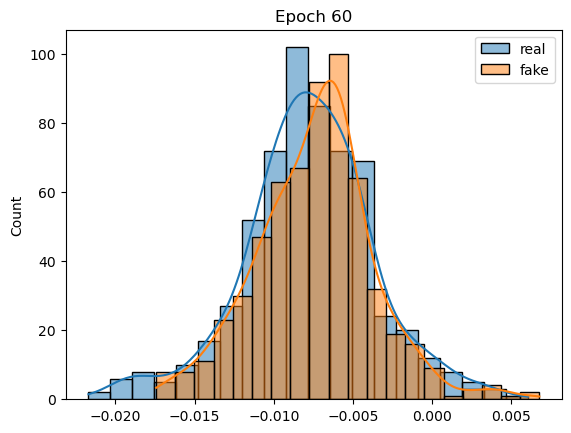

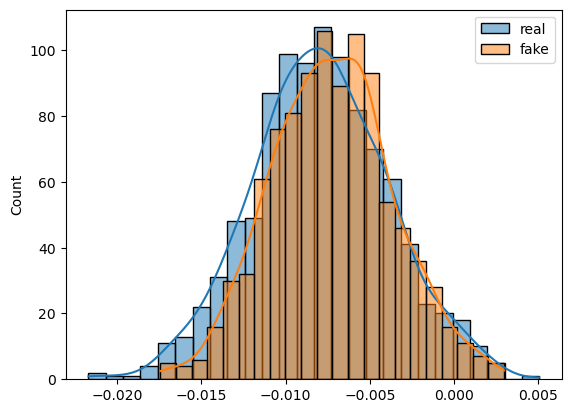

In [21]:
fake_scores = fake_pred.cpu().detach().numpy().flatten()
real_scores = real_pred.cpu().detach().numpy().flatten()

sns.histplot(real_scores, bins=20, alpha=0.5, label='real', kde=True)
sns.histplot(fake_scores, bins=20, alpha=0.5, label='fake', kde=True)
plt.legend()
plt.title(f'Epoch {EPOCH}')
plt.show()

# plot a normal distribution using the mean and std and min and max values of the critic scores
f_scores = np.random.normal(fake_scores.mean(), fake_scores.std(), 1000)
r_scores = np.random.normal(real_scores.mean(), real_scores.std(), 1000)

# Clip the generated scores to the min and max values of the real and fake scores
r_scores = np.clip(r_scores, real_scores.min(), real_scores.max())
f_scores = np.clip(f_scores, fake_scores.min(), fake_scores.max())

sns.histplot(r_scores, label='real', kde=True)
sns.histplot(f_scores, label='fake', kde=True)
plt.legend()

# test if Critic is underpowered

In [ ]:
model = FiLMGAN(512, 8, 128, 202)

model.critic.predict(data)

In [79]:
model.critic.summary()

Model: "critic_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ torch_module_wrapper_95         │ ?                      │         6,464 │
│ (TorchModuleWrapper)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ torch_module_wrapper_96         │ ?                      │            32 │
│ (TorchModuleWrapper)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ torch_module_wrapper_97         │ ?                      │           802 │
│ (TorchModuleWrapper)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ high_pass1d_12 (HighPass1D)     │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (32, 512, 8)           │           648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_68 (LeakyReLU)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv1D)                  │ (32, 256, 16)          │           656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_69 (LeakyReLU)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv1D)                  │ (32, 128, 128)         │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_70 (LeakyReLU)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d_gap (GlobalAveragePooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dis_flatten (Flatten)           │ (32, 16512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dis_dense6 (Dense)              │ (32, 1)                │        20,609 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ minibatch_std_dev_12            │ ?                      │             0 │
│ (MinibatchStdDev)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,580 (154.61 KB)

 Trainable params: 39,580 (154.61 KB)

 Non-trainable params: 0 (0.00 B)